In [3]:
import geopandas as gpd
wards = gpd.read_file("https://raw.githubusercontent.com/datameet/Municipal_Spatial_Data/master/Kolkata/kolkata.geojson")
print(wards.columns.tolist())
print(wards.head(3))

['WARD', 'geometry']
  WARD                                           geometry
0   93  MULTIPOLYGON (((88.35296 22.50168, 88.353 22.5...
1   61  MULTIPOLYGON (((88.35655 22.55349, 88.35656 22...
2   86  MULTIPOLYGON (((88.35978 22.52516, 88.35979 22...


In [6]:
import geopandas as gpd

gdf = gpd.read_file("../../outputs/ward_heat_summary.geojson")
missing = gdf[gdf["PREDICTED_LST_C"].isna()]
print(missing[["WARD"]])
print(missing.geometry.isna().sum(), "with missing geometry")
print(len(gdf), "total wards,", gdf["PREDICTED_LST_C"].isna().sum(), "missing predictions")

Empty DataFrame
Columns: [WARD]
Index: []
0 with missing geometry
141 total wards, 0 missing predictions


In [9]:
import geopandas as gpd

wards = gpd.read_file("https://raw.githubusercontent.com/datameet/Municipal_Spatial_Data/master/Kolkata/kolkata.geojson")
print(len(wards), "rows in raw file")
print(wards["WARD"].nunique(), "unique ward numbers")
unique_wards = wards["WARD"].unique()
ward_nos = []
for ward in unique_wards:
    ward_nos.append(int(ward))
print(sorted(ward_nos))

141 rows in raw file
141 unique ward numbers
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141]


In [ ]:
print(wards.crs)

EPSG:4326


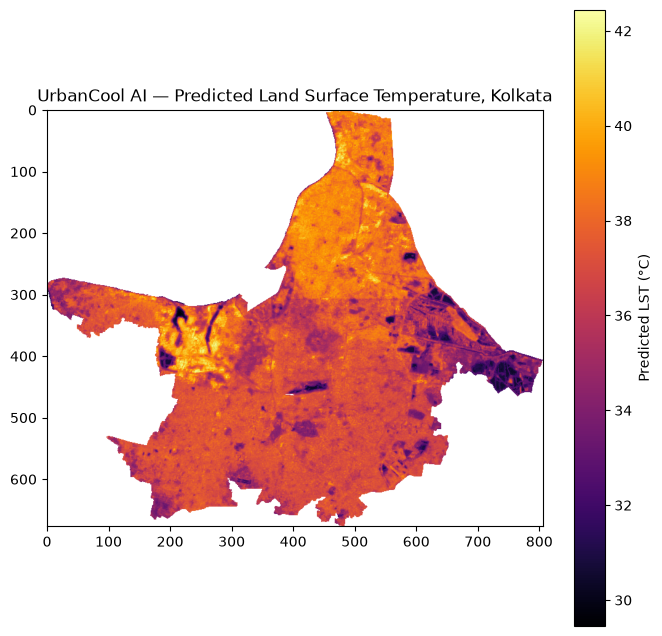

In [2]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open("../../outputs/predicted_lst_raster.tif") as src:
    data = src.read(1)

plt.figure(figsize=(8, 8))
plt.imshow(data, cmap="inferno")
plt.colorbar(label="Predicted LST (°C)")
plt.title("UrbanCool AI — Predicted Land Surface Temperature, Kolkata")
plt.savefig("../../outputs/heatmap_preview.png", dpi=150)
plt.show()